<a href="https://colab.research.google.com/github/dezurnyjkipia4/DataScince/blob/main/HW3/HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Установка библиотек
!pip install openpyxl
!pip install pyyaml
!pip install pyarrow
import pandas as pd

In [38]:
data = pd.read_csv("mercedes_benz_stock_refined.csv")
data.head() # посмотрим на данные

,Date,Open,High,Low,Price,Volume,Daily_Return,Price_Change,Price_Range,MA_7,MA_30,MA_90,Volatility_30,Day_of_Week,Month,Year,Quarter
0,1996-10-30,9.97,9.97,9.88,9.89,1640521,NaN,-0.08,0.09,9.89,9.89,9.89,NaN,Wednesday,10,1996,4
1,1996-10-31,9.91,10.02,9.91,10.02,1908031,1.34,0.11,0.11,9.95,9.95,9.95,NaN,Thursday,10,1996,4
2,1996-11-01,10.08,10.17,10.03,10.07,2423211,0.47,-0.01,0.14,9.99,9.99,9.99,0.61,Friday,11,1996,4
3,1996-11-04,10.08,10.17,10.08,10.14,1284644,0.78,0.07,0.09,10.03,10.03,10.03,0.44,Monday,11,1996,4
4,1996-11-05,10.19,10.34,10.14,10.34,2105206,1.88,0.15,0.20,10.09,10.09,10.09,0.62,Tuesday,11,1996,4


In [43]:
import sqlite3
import pandas as pd

# Подключиться к базе данных SQLite
conn = sqlite3.connect('example.db')

# Проверка, что колонка 'Date' преобразована в строку
data['Date'] = data['Date'].astype(str)

# Записать DataFrame в таблицу 'statistic'
data.to_sql('statistic', conn, if_exists='replace', index=False)

# Закрыть соединение с базой данных
conn.close()

print("Data successfully loaded into 'statistic' table in example.db")
print("Данные из таблицы 'statistic':")
print(df_statistic)

Data successfully loaded into 'statistic' table in example.db
Данные из таблицы 'statistic':
            Date   Open   High    Low  Price   Volume  Daily_Return  \
0     1996-10-30   9.97   9.97   9.88   9.89  1640521           NaN   
1     1996-10-31   9.91  10.02   9.91  10.02  1908031          1.34   
2     1996-11-01  10.08  10.17  10.03  10.07  2423211          0.47   
3     1996-11-04  10.08  10.17  10.08  10.14  1284644          0.78   
4     1996-11-05  10.19  10.34  10.14  10.34  2105206          1.88   
...          ...    ...    ...    ...    ...      ...           ...   
7335  2026-01-26  58.10  58.76  57.92  57.92  1364803         -0.65   
7336  2026-01-27  57.88  57.94  56.76  56.93  2587541         -1.71   
7337  2026-01-28  56.40  57.63  55.95  57.41  1761238          0.84   
7338  2026-01-29  58.73  58.89  57.29  57.30  1954651         -0.19   
7339  2026-01-30  57.63  57.87  57.04  57.79  2511343          0.86   

      Price_Change  Price_Range   MA_7  MA_30  MA_90  

In [44]:
#Напишите несколько SQL-запросов для извлечения данных из таблиц базы данных.
#Используйте условия фильтрации (например, WHERE) для получения нужных данных.
import sqlite3
import pandas as pd

# Подключение к базе данных SQLite
conn = sqlite3.connect('example.db')

print("Данные за все время:")
# Запрос всех данных из таблицы statistic
df_all = pd.read_sql_query("SELECT * FROM statistic LIMIT 10", conn)
display(df_all)

print("\nДанные за 2025 год:")
# Запрос данных за конкретный год (например, 2020)
df_2025 = pd.read_sql_query("SELECT * FROM statistic WHERE Year = 2025 LIMIT 10", conn)
display(df_2025)

print("\nДанные только по понедельникам:")
# Запрос данных по конкретному дню недели (например, понедельник)
df_monday = pd.read_sql_query("SELECT * FROM statistic WHERE Day_of_Week = 'Monday' LIMIT 10", conn)
display(df_monday)

print("\nДанные за 2022 год с положительным сальдо:")
# Запрос данных за 2022 год с положительным сальдо
df_2022_positive = pd.read_sql_query("SELECT * FROM statistic WHERE Year = 2022 AND Daily_Return > 0 LIMIT 10", conn)
display(df_2022_positive)

# Закрытие соединения
conn.close()

Данные за все время:


,Date,Open,High,Low,Price,Volume,Daily_Return,Price_Change,Price_Range,MA_7,MA_30,MA_90,Volatility_30,Day_of_Week,Month,Year,Quarter
0,1996-10-30,9.97,9.97,9.88,9.89,1640521,NaN,-0.08,0.09,9.89,9.89,9.89,NaN,Wednesday,10,1996,4
1,1996-10-31,9.91,10.02,9.91,10.02,1908031,1.34,0.11,0.11,9.95,9.95,9.95,NaN,Thursday,10,1996,4
2,1996-11-01,10.08,10.17,10.03,10.07,2423211,0.47,-0.01,0.14,9.99,9.99,9.99,0.61,Friday,11,1996,4
3,1996-11-04,10.08,10.17,10.08,10.14,1284644,0.78,0.07,0.09,10.03,10.03,10.03,0.44,Monday,11,1996,4
4,1996-11-05,10.19,10.34,10.14,10.34,2105206,1.88,0.15,0.20,10.09,10.09,10.09,0.62,Tuesday,11,1996,4
5,1996-11-06,10.39,10.49,10.36,10.49,2973859,1.53,0.10,0.14,10.16,10.16,10.16,0.57,Wednesday,11,1996,4
6,1996-11-07,10.49,10.50,10.31,10.44,2894508,-0.54,-0.05,0.20,10.20,10.20,10.20,0.87,Thursday,11,1996,4
7,1996-11-08,10.50,10.55,10.48,10.48,2001809,0.38,-0.02,0.07,10.28,10.23,10.23,0.82,Friday,11,1996,4
8,1996-11-11,10.47,10.53,10.46,10.52,1020742,0.45,0.05,0.06,10.35,10.26,10.26,0.77,Monday,11,1996,4
9,1996-11-12,10.51,10.76,10.47,10.76,2786903,2.27,0.25,0.29,10.45,10.31,10.31,0.88,Tuesday,11,1996,4



Данные за 2025 год:


,Date,Open,High,Low,Price,Volume,Daily_Return,Price_Change,Price_Range,MA_7,MA_30,MA_90,Volatility_30,Day_of_Week,Month,Year,Quarter
0,2025-01-02,49.33,49.65,47.87,48.67,2393516,-1.71,-0.66,1.79,49.15,49.13,51.83,1.48,Thursday,1,2025,1
1,2025-01-03,48.52,48.84,48.05,48.27,1477736,-0.81,-0.25,0.79,48.95,49.16,51.75,1.47,Friday,1,2025,1
2,2025-01-06,48.77,51.21,48.66,50.01,4114191,3.60,1.24,2.55,49.07,49.22,51.68,1.57,Monday,1,2025,1
3,2025-01-07,49.70,50.10,49.02,49.99,2438201,-0.04,0.29,1.09,49.18,49.26,51.60,1.56,Tuesday,1,2025,1
4,2025-01-08,49.71,50.07,48.72,49.06,2450937,-1.86,-0.64,1.34,49.26,49.25,51.52,1.59,Wednesday,1,2025,1
5,2025-01-09,48.74,48.94,48.20,48.83,1767039,-0.47,0.09,0.75,49.19,49.26,51.43,1.58,Thursday,1,2025,1
6,2025-01-10,48.68,51.25,48.29,50.66,4544291,3.73,1.98,2.95,49.36,49.36,51.35,1.68,Friday,1,2025,1
7,2025-01-13,50.84,51.77,50.71,51.03,2274840,0.74,0.19,1.06,49.70,49.47,51.28,1.68,Monday,1,2025,1
8,2025-01-14,51.25,52.09,51.13,51.13,1945433,0.18,-0.12,0.97,50.10,49.57,51.21,1.67,Tuesday,1,2025,1
9,2025-01-15,51.30,52.03,50.81,51.82,2285596,1.35,0.52,1.21,50.36,49.67,51.15,1.68,Wednesday,1,2025,1



Данные только по понедельникам:


,Date,Open,High,Low,Price,Volume,Daily_Return,Price_Change,Price_Range,MA_7,MA_30,MA_90,Volatility_30,Day_of_Week,Month,Year,Quarter
0,1996-11-04,10.08,10.17,10.08,10.14,1284644,0.78,0.07,0.09,10.03,10.03,10.03,0.44,Monday,11,1996,4
1,1996-11-11,10.47,10.53,10.46,10.52,1020742,0.45,0.05,0.06,10.35,10.26,10.26,0.77,Monday,11,1996,4
2,1996-11-18,10.94,10.95,10.78,10.81,1451161,-1.11,-0.13,0.16,10.63,10.41,10.41,1.03,Monday,11,1996,4
3,1996-11-25,10.96,11.12,10.96,11.11,1502860,1.90,0.15,0.16,10.90,10.55,10.55,0.98,Monday,11,1996,4
4,1996-12-02,11.25,11.44,11.23,11.39,1104301,0.89,0.13,0.21,11.15,10.70,10.70,0.95,Monday,12,1996,4
5,1996-12-09,11.31,11.47,11.30,11.45,1419902,2.10,0.15,0.17,11.47,10.86,10.86,1.34,Monday,12,1996,4
6,1996-12-16,11.14,11.48,11.06,11.38,1808241,2.16,0.24,0.42,11.29,10.99,10.92,1.40,Monday,12,1996,4
7,1996-12-23,11.40,11.49,11.40,11.44,423806,0.20,0.04,0.10,11.30,11.16,10.98,1.40,Monday,12,1996,4
8,1996-12-30,11.71,11.91,11.71,11.89,977460,2.07,0.17,0.20,11.45,11.24,11.02,1.46,Monday,12,1996,4
9,1997-01-06,11.87,12.24,11.87,12.24,2076351,3.31,0.37,0.37,11.73,11.35,11.08,1.58,Monday,1,1997,1



Данные за 2022 год с положительным сальдо:


,Date,Open,High,Low,Price,Volume,Daily_Return,Price_Change,Price_Range,MA_7,MA_30,MA_90,Volatility_30,Day_of_Week,Month,Year,Quarter
0,2022-01-03,50.12,50.63,49.67,50.27,2654611,1.64,0.15,0.95,50.57,51.99,49.37,2.08,Monday,1,2022,1
1,2022-01-04,50.84,53.14,50.79,52.76,4936145,4.96,1.92,2.36,50.82,51.93,49.48,2.28,Tuesday,1,2022,1
2,2022-01-05,52.97,54.91,52.97,54.88,5106683,4.01,1.90,1.94,51.34,51.91,49.60,2.39,Wednesday,1,2022,1
3,2022-01-12,53.71,54.17,53.00,53.72,2946446,1.21,0.01,1.17,53.79,52.09,50.20,2.12,Wednesday,1,2022,1
4,2022-01-13,53.57,55.32,53.56,55.19,3906108,2.74,1.62,1.76,54.14,52.25,50.34,2.17,Thursday,1,2022,1
5,2022-01-18,54.07,55.03,53.27,54.61,2955090,0.51,0.54,1.76,54.16,52.47,50.76,2.04,Tuesday,1,2022,1
6,2022-01-25,50.63,51.06,49.77,50.36,3132631,0.76,-0.28,1.29,52.85,52.37,51.22,2.16,Tuesday,1,2022,1
7,2022-01-26,50.80,52.00,50.61,51.59,2931917,2.46,0.79,1.39,52.46,52.29,51.33,2.21,Wednesday,1,2022,1
8,2022-01-27,50.82,52.52,50.71,52.06,2960980,0.91,1.24,1.81,52.10,52.28,51.44,2.13,Thursday,1,2022,1
9,2022-01-31,51.67,51.82,50.63,51.17,2650761,0.09,-0.50,1.19,51.27,52.20,51.60,2.15,Monday,1,2022,1


In [45]:
#Напишите SQL-запросы, использующие агрегатные функции (SUM, AVG, COUNT)
#для выполнения расчетов по данным таблицы.
import sqlite3
import pandas as pd

# Подключение к базе данных SQLite
conn = sqlite3.connect('example.db')

print("Общее количество записей:")
df_count = pd.read_sql_query("SELECT COUNT(*) FROM statistic", conn)
display(df_count)

print("\nСредняя дневная доходность:")
df_avg_daily_return = pd.read_sql_query("SELECT AVG(Daily_Return) FROM statistic", conn)
display(df_avg_daily_return)

print("\nСумма дневной доходности за 2022 год:")
df_sum_2022 = pd.read_sql_query("SELECT SUM(Daily_Return) FROM statistic WHERE Year = 2022", conn)
display(df_sum_2022)

print("\nКоличество дней с положительной доходностью:")
df_positive_days = pd.read_sql_query("SELECT COUNT(*) FROM statistic WHERE Daily_Return > 0", conn)
display(df_positive_days)

print("\nСредняя дневная доходность по годам:")
df_avg_by_year = pd.read_sql_query("SELECT Year, AVG(Daily_Return) FROM statistic GROUP BY Year ORDER BY Year", conn)
display(df_avg_by_year)

# Закрытие соединения
conn.close()

Общее количество записей:


,COUNT(*)
0,7340



Средняя дневная доходность:


,AVG(Daily_Return)
0,0.04717



Сумма дневной доходности за 2022 год:


,SUM(Daily_Return)
0,5.22



Количество дней с положительной доходностью:


,COUNT(*)
0,3697



Средняя дневная доходность по годам:


,Year,AVG(Daily_Return)
0,1996,0.495526
1,1997,0.091138
2,1998,0.141673
3,1999,-0.003241
4,2000,-0.186375
5,2001,0.088279
6,2002,-0.144980
7,2003,0.141897
8,2004,0.010545
9,2005,0.107121


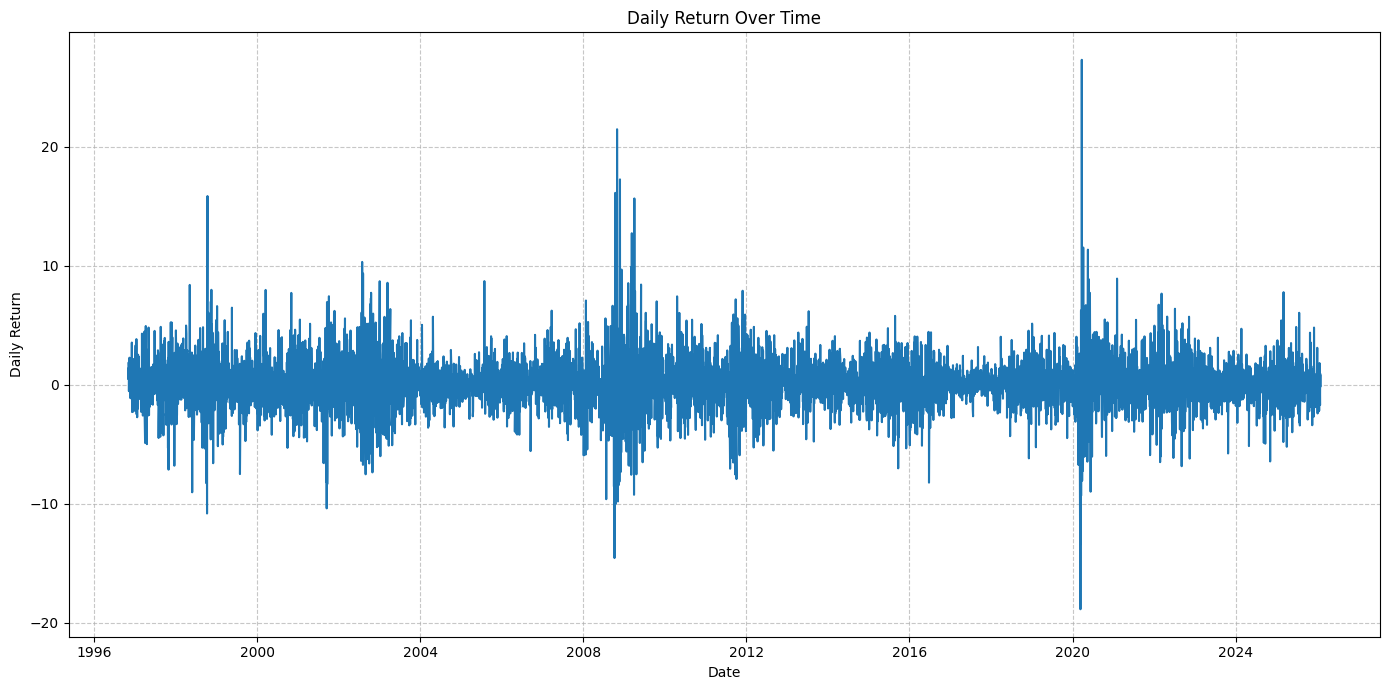

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Убедимся, что столбец 'Date' имеет тип datetime для правильного отображения на оси X
df_statistic['Date'] = pd.to_datetime(df_statistic['Date'])

plt.figure(figsize=(14, 7))
sns.lineplot(x='Date', y='Daily_Return', data=df_statistic)
plt.title('Daily Return Over Time')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

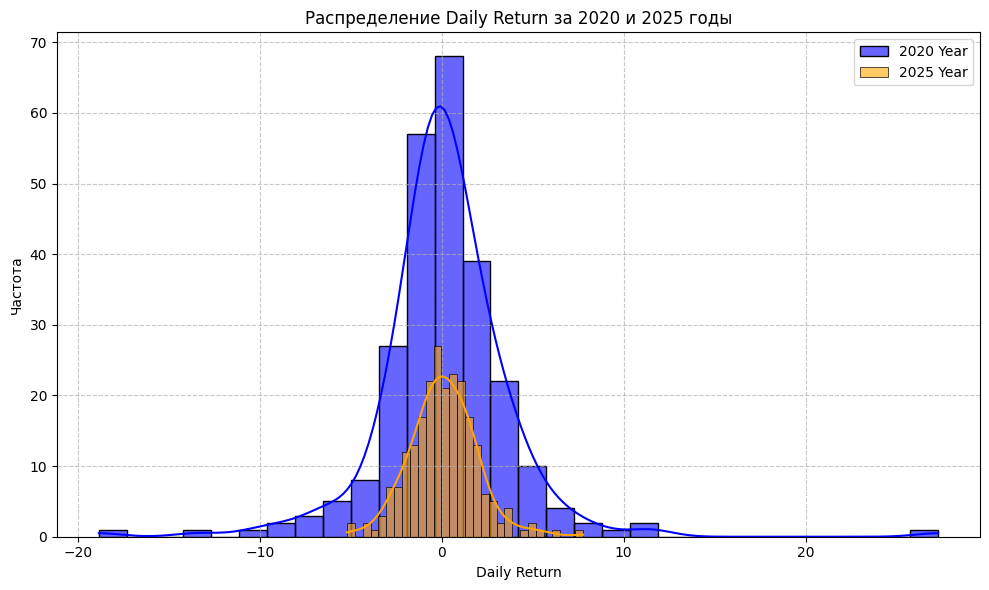

In [26]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Подключение к базе данных SQLite
conn = sqlite3.connect('example.db')

# Запрос данных за 2025 год и 2020 год из таблицы statistic
df_2020 = pd.read_sql_query("SELECT Daily_Return FROM statistic WHERE Year = 2020", conn)
df_2025 = pd.read_sql_query("SELECT Daily_Return FROM statistic WHERE Year = 2025", conn)

# Закрытие соединения
conn.close()

# Построение гистограмм на одном графике
plt.figure(figsize=(10, 6))
sns.histplot(df_2020['Daily_Return'].dropna(), kde=True, bins=30, color='blue', label='2020 Year', alpha=0.6)
sns.histplot(df_2025['Daily_Return'].dropna(), kde=True, bins=30, color='orange', label='2025 Year', alpha=0.6)
plt.title('Распределение Daily Return за 2020 и 2025 годы')
plt.xlabel('Daily Return')
plt.ylabel('Частота')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [47]:

#анализ графика за 20 и 25 года по количеству данных в БД
import sqlite3
import pandas as pd

# Подключение к базе данных SQLite
conn = sqlite3.connect('example.db')

print("Количество записей за 2020 год:")
df_count_2020 = pd.read_sql_query("SELECT COUNT(*) FROM statistic WHERE Year = 2020", conn)
display(df_count_2020)

print("\nКоличество записей за 2025 год:")
df_count_2025 = pd.read_sql_query("SELECT COUNT(*) FROM statistic WHERE Year = 2025", conn)
display(df_count_2025)

# Закрытие соединения
conn.close()

Количество записей за 2020 год:


,COUNT(*)
0,254



Количество записей за 2025 год:


,COUNT(*)
0,232
